# Deep Learning-Based Emulation of the Fire Weather Index in the Iberian Peninsula Using ERA5-Land Predictors: A toy example.

*Óscar Mirones*, *Joaquín Bedia* y *Jorge Baño-Medina*

This notebook provides a straightforward example of how to design and train two different deep learning models: a **Fully Connected Dense (FCD)** and a **U-Net** model.

The Fully Connected Dense (FCD) network is one of the simplest deep learning architectures in the literature, consisting of a sequence of densely connected layers. In contrast, the U-Net model features a fully convolutional architecture, meaning that all layers are convolutional rather than dense. The U-Net is characterized by its distinctive "U-shaped" structure, in which the input data is progressively compressed and then decompressed, allowing the model to capture and extract high-level features hidden within the input.

- **Objective**:
  The primary objective of this notebook is to build and train deep learning models capable of emulating the Fire Weather Index (FWI) using daily mean meteorological variables such as temperature, relative humidity, and wind speed.

- **Key Tools and Libraries**:
To achieve this, the notebook leverages libraries from the climate4R framework, which are essential for tasks such as data loading, preprocessing, visualization, and constructing, training, and evaluating deep learning models.

## The climate4R framework

To handle with climate data is neccessary to instal `climate4r` libraries. 

This framework is a bundle of R packages for transparent climate data access, post-processing (including data collocation and bias correction / downscaling) and visualization. `climate4R` builds on two main data structures (grid and station, including metadata) to deal with gridded and point data from observations, reanalysis, seasonal forecasts and climate projections. It considers ensemble members as a basic dimension of the data structures. Moreover, `climate4R` is transparently (and remotely) connected to the Santander Climate Data Gateway, offering several state-of-the-art datasets (including CMIP5 and CORDEX subsets).

* `climate4R` is formed by the following four core packages (all in GitHub): [`loadeR`](https://github.com/SantanderMetGroup/loadeR) , [`transformeR`](https://github.com/SantanderMetGroup/transformeR), [`downscaleR`](https://github.com/SantanderMetGroup/downscaleR) and [`visualizeR`](https://github.com/SantanderMetGroup/visualizeR). These packages are fully documented in the corresponding GitHub wikis.

* `climate4R` capabilities are further extended by providing support to physical units handling ([`convertR`](https://github.com/SantanderMetGroup/convertR) package) and geoprocessing tasks ([`geoprocessoR`](https://github.com/SantanderMetGroup/geoprocessoR) package).   

* Compatibility with some external packages has been achieved by wrapping packages, thus enhancing `climate4R` with new functionalities (e.g. ETCCDI extreme climate indices via the [`climdex`](https://github.com/pacificclimate/climdex.pcic) package). 

* Semantic provenance (metadata) information for `climate4R` products can be generated using [METACLIP](http://www.metaclip.org) via the [`metaclipR`](https://github.com/metaclip/metaclipR) package.

* [Conda](https://github.com/SantanderMetGroup/climate4R/tree/master/conda) and [docker](https://github.com/SantanderMetGroup/climate4R/tree/master/docker) `climate4R` installations available. The [docker](https://www.docker.com/why-docker) file also includes the [jupyter](https://jupyter.readthedocs.io/en/latest) framework. This is the base layer for the **climate4R Hub** (a cloud-based computing facility to run `climate4R` notebooks at [IFCA/CSIC Cloud Services](https://ifca.unican.es/en-us/research/advanced-computing-and-e-science)).

#### References and Examples


The **formal reference** of `climate4R` is: 

****
M. Iturbide, J. Bedia, S. Herrera, J. Baño-Medina, J. Fernández, M.D. Frías, R. Manzanas, D. San-Martín, E. Cimadevilla, A.S. Cofiño and JM Gutiérrez (2019) The R-based climate4R open framework for reproducible climate data access and post-processing. *Environmental Modelling & Software*, **111**, 42-54. [DOI: /10.1016/j.envsoft.2018.09.009](https://doi.org/10.1016/j.envsoft.2018.09.009)
****

Additional references for **specific components** of `climate4R` (with worked examples) are [Cofiño _et al._ 2018](http://doi.org/10.1016/j.cliser.2017.07.001) (seasonal forecasting ), [Frías _et al._ 2018](http://doi.org/10.1016/j.envsoft.2017.09.008) (visualization),  [Bedia _et al._ 2019](https://doi.org/10.1016/j.envsoft.2019.07.005) (data provenance) and [Bedia _et al._ 2019a](https://doi.org/10.5194/gmd-2019-224) (statistical downscaling). Other publications describing applications in **sectoral impact studies** (also with worked out examples) are [Bedia _et al._ (2018)](http://doi.org/10.1016/j.cliser.2017.04.001) (fire danger) or [Iturbide _et al._ (2018)](https://journal.r-project.org/archive/2018/RJ-2018-019/index.html) (Species distribution models), among others.
<!-- 
* [Cofiño et al. 2018](http://doi.org/10.1016/j.cliser.2017.07.001) (seasonal forecasting )
 * [Frías et al. 2018](http://doi.org/10.1016/j.envsoft.2017.09.008) (visualization). 

Other publications describing applications of `climate4R` in **sectoral impact studies** (with worked out examples):

 * **Fire danger:** [Bedia et al. (2018)](http://doi.org/10.1016/j.cliser.2017.04.001) Seasonal predictions of Fire Weather Index: Paving the way for their operational applicability in Mediterranean Europe. *Climate Services*, **9**, 101-110. 

 * **Species distribution models:** [Iturbide et al. (2018)](https://journal.r-project.org/archive/2018/RJ-2018-019/index.html) Tackling Uncertainties of Species Distribution Model Projections with Package mopa. *The R Journal*, **10**(1), 122-139. 
-->

Moreover, there is a [notebook repository](https://github.com/SantanderMetGroup/notebooks) including several illustrative **notebooks with worked-out examples** (which are companion material of several papers). 

#### Installation (Recommended)

The `climate4R` framework relies on a wealth of other R packages and bindings to third-party libraries. Therefore, the recommended installation is through the conda package below, which ensures the proper installation of all dependencies.
To an easy installation, open a new terminal in Jupyter and then:

```bash

# Create environment using mamba for faster dependency resolution
conda create -n deep-fwi -c conda-forge mamba

# Activate environment
conda activate deep-fwi

# Use Mamba to install the packages required
mamba env create -f environment.yaml

```

#### Direct package installation from github (not recommended):

Individual packages can be installed directly from the github sources.

``` r
    > library(devtools)
    > install_github(c("SantanderMetGroup/loadeR.java",
                 "SantanderMetGroup/climate4R.UDG",
                 "SantanderMetGroup/loadeR",
                 "SantanderMetGroup/transformeR",
                 "SantanderMetGroup/visualizeR",
                 "SantanderMetGroup/downscaleR"))
```

#### NOTE: installation of specific package versions

In case a particular paper notebook is to be replicated, the installation of specific version tags can be done by just explicitly indicating the tag number in the repo name. For example:

```r
   > devtools::install_github("SantanderMetGroup/visualizeR@v1.0.0")
   
```
installs the `visualizeR` package version used in Frías _et al._ 2018, while the following

```r
   > devtools::install_github("SantanderMetGroup/visualizeR@v1.4.6")
   
```
will install a more recent version of the package used in the paper by Iturbide _et al._ 2019.


#### Example of use

Examples of use of the `climate4R` framework are given in the reference papers above. In the following we illustrate the main functionalities of `climate4R` with a simple example, consisting on **calculating an ETCCDI index (Summer Days) from bias corrected EURO-CORDEX data over Southern Europe.** More details at the [brief introduction to climate4R](/man/2018_ClimateInformatics_Gutierrez.pdf) document in the `man` folder and full code at the companion [jupyter notebook](/man/notebooks/climate4R.ipynb).


***
#### User Support

Please note that the pool of people who can provide support for `climate4R` packages is very small and our time for support is limited. We don't necessarily have the capacity for long, open-ended user support. Please follow these basic guidelines before posting:

* Introduce the problem before you post any code
* Help others reproduce the problem
* Avoid sending the same question to multiple places

These [posting guidelines](https://stackoverflow.com/help/how-to-ask) at stackoverflow provide further recommendations on how to make a good question. If questions are kept short, specific and direct, there's a greater chance that someone will take on the ticket. 

***

### Loading requiered libraries

#### climate4R libraries

Firstly, we load the `climate4R` libraries needed to handle with climate data and run the notebook. Specifically, we use four key `climate4R` libraries. 
- **`loadeR`**: `loadeR` is an R package for climate data access building on the NetCDF-Java API. It allows user-friendly data access either from local or remote locations (e.g. OPeNDAP servers) and it is fully integrated with the User Data Gateway ([UDG](http://www.meteo.unican.es/udg-wiki)), a Climate Data Service deployed and maintained by the [Santander Meteorology Group](http://www.meteo.unican.es). loadeR has been conceived to work in the framework of both seasonal forecasting and climate change studies. Thus, it considers ensemble members as a basic dimension of its two main data structures (`grid` and `station`). Find out more about this package at the [loadeR wiki](https://github.com/SantanderMetGroup/loadeR/wiki).

- **`transformeR`**: `transformeR` is an R package for climate data manipulation and transformation including subsetting, regridding and data conversion. Find out more about this package at the [transformeR wiki](https://github.com/SantanderMetGroup/transformeR/wiki).

- **`visualizeR`**: `visualizeR` is an R package for climate data visualization, with special focus on ensemble forecasting and uncertainty communication. It includes functions for visualizing climatological, forecast and evaluation products, and combinations of them. Find out more about this package at the [visualizeR wiki](https://github.com/SantanderMetGroup/visualizeR/wiki).

- **`downscaleR.keras`**: `downwscaleR.keras` is an R package for statistical downscaling of daily data based on neural networks. This library integrates the deep learning package Keras in the `climate4R` framework. This permits to incorporate sophisticated convolutional or recurrent neural networks, among others, to the climate4R battery of downscaling methods. Some degree of knowledge regarding the use of keras is required and we refer the reder to specific tutorials to better exploit the benefits of this library.

In [1]:
options(java.parameters = "-Xmx8g") 

In [2]:
library(loadeR) 
library(transformeR) 
library(visualizeR)
library(downscaleR.keras) 

Loading required package: rJava

Loading required package: loadeR.java

Java version 23x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.3) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

Loading required package: downscaleR

downscaleR version 3.3.4 (2023-06-22) is loaded

Please use 'citation("downscaleR")' to cite this package.

Loading required package: keras

Loading required package: tensorflow



`magrittr` enable to concatenate operations using `%>%` or `%<>%`, `keras` and `tensorflow` are deep learning libraries for building, optimization and training. `RColorBrewer` is used to define colorbars and `ggplot2` for visualization.

In [3]:
library(magrittr) # to operate with '%>%' or '%<>%'
library(keras)
library(yaml)
library(RColorBrewer)
library(ggplot2)
library(tensorflow)

It is necessary to install TensorFlow in the R environment the first time this notebook is run. This can be done by simply executing the cell below.

In [4]:
#tensorflow::install_tensorflow() #run just the first time to install tensorflow

The `config_nb.yaml` file stores various parameters used to train and optimize the deep learning models. This approach provides a simple and convenient way to adjust optimization settings without modifying the notebook's code. If users want to train the deep learning models with different parameter values, they only need to update the corresponding entries in the `.yaml` file. The parameters available for customization include the `batch size`, number of `epochs`, `patience` value, and `learning rate`.

In [5]:
#read .yaml file
config <- yaml.load_file("config_nb.yaml")

In [6]:
print(config$params)

$batch
[1] 64

$epochs
[1] 80

$patience
[1] 5

$learning_rate
[1] 1e-04



## Data downloading, loading and preprocessing

First, download the necessary data to run this notebook:

Mirones, Ó., Bedia Jiménez, J., & Baño-Medina, J. (2025). Toy Dataset for Emulating the Fire Weather Index (FWI) Using Deep Learning Techniques [Data set]. Zenodo. https://doi.org/10.5281/zenodo.15075367

The following cells create a `data` directory and download the dataset from the Zenodo repository, storing it in the newly created directory.

In [25]:
#urls links for the data
file_urls <- c("https://zenodo.org/records/15075367/files/yTrain.nc?download=1",
              "https://zenodo.org/records/15075367/files/yTest.nc?download=1",
              "https://zenodo.org/records/15075367/files/t2m_Train.nc?download=1",
              "https://zenodo.org/records/15075367/files/sfcwind_Train.nc?download=1",
              "https://zenodo.org/records/15075367/files/hurs_Train.nc?download=1",
              "https://zenodo.org/records/15075367/files/xTest_stand.Rdata?download=1",
              "https://zenodo.org/records/15075367/files/unet_P1.h5?download=1",
              "https://zenodo.org/records/15075367/files/dense_P1.h5?download=1")

In [12]:
# Check if the 'data' directory exists, and create it if it doesn't
if (!dir.exists("data")) {
  dir.create("data")
  message("Directory 'data' created.")
} else {
  message("Directory 'data' already exists.")
}


Directory 'data' already exists.



In [26]:
options(timeout = 300)  # Set timeout to avoid download failure due to slowness

# Loop to download all files
for (file_url in file_urls) {
  file_name <- sub("\\?.*", "", basename(file_url))
  full_file_name <- paste0("data/", file_name)
  download.file(file_url, full_file_name, mode = "wb")
}

For any predictive model, it is necessary to train the model using both the predictand (the target values that the model aims to learn) and the predictors (the input variables used by the model to make predictions).

In the cell below, the predictand data is prepared for training the deep learning models using the `loadGridData` function. This function requires the following arguments: the path to the data, the variable name, and the range of years to select. The data is stored in NetCDF format, which is a standard file format commonly used for climate datasets.

Additionally, there is an option to inspect key characteristics of the data before performing the loading operation by using the `dataInventory` function.

In [7]:
inv <- dataInventory("data/yTrain.nc")

[2025-03-21 18:18:22.974065] Doing inventory ...

[2025-03-21 18:18:23.921101] Retrieving info for 'FWI' (0 vars remaining)

[2025-03-21 18:18:24.009022] Done.



In [8]:
print(inv)

$FWI
$FWI$Description
[1] "FWI"

$FWI$DataType
[1] "float"

$FWI$Shape
[1] 14245    80   160

$FWI$Units
[1] "adimensional"

$FWI$DataSizeMb
[1] 729.344

$FWI$Version
[1] NA

$FWI$Dimensions
$FWI$Dimensions$time
$FWI$Dimensions$time$Type
[1] "Time"

$FWI$Dimensions$time$TimeStep
[1] "1.0 days"

$FWI$Dimensions$time$Units
[1] "days since 1979-01-01 12:00:00 GMT"

$FWI$Dimensions$time$Date_range
[1] "1979-01-01T12:00:00Z - 2017-12-31T12:00:00Z"


$FWI$Dimensions$lat
$FWI$Dimensions$lat$Type
[1] "Lat"

$FWI$Dimensions$lat$Units
[1] "degrees_north"

$FWI$Dimensions$lat$Values
 [1] 36.1 36.2 36.3 36.4 36.5 36.6 36.7 36.8 36.9 37.0 37.1 37.2 37.3 37.4 37.5
[16] 37.6 37.7 37.8 37.9 38.0 38.1 38.2 38.3 38.4 38.5 38.6 38.7 38.8 38.9 39.0
[31] 39.1 39.2 39.3 39.4 39.5 39.6 39.7 39.8 39.9 40.0 40.1 40.2 40.3 40.4 40.5
[46] 40.6 40.7 40.8 40.9 41.0 41.1 41.2 41.3 41.4 41.5 41.6 41.7 41.8 41.9 42.0
[61] 42.1 42.2 42.3 42.4 42.5 42.6 42.7 42.8 42.9 43.0 43.1 43.2 43.3 43.4 43.5
[76] 43.6 43.7 43.8 4

Since loading multiple years of high-resolution climate data and training deep learning models on it can be computationally intensive, it is recommended to limit the dataset to the first five available years for training (*yTrain*). Additionally, reducing the data resolution can further decrease computational time.

In this experiment, the data is regridded from a 0.1º resolution to 0.5º. This dataset represents the ERA5-Land computed Fire Weather Index (FWI) for the Iberian Peninsula.

In [9]:
yTrain <- loadGridData("data/yTrain.nc", var = "FWI", years = 1979:1984)

[2025-03-21 18:18:24.326931] Defining geo-location parameters

[2025-03-21 18:18:24.36914] Defining time selection parameters

[2025-03-21 18:18:24.452579] Retrieving data subset ...

[2025-03-21 18:18:51.873593] Done



Using functions from the `RColorBrewer` library, it is possible to customize the colorbar for data visualization. The `spatialPlot` function from the `visualizeR` package allows users to create spatial plots of the data. This function requires a climatology dataset as input, which is typically a two-dimensional *latitude × longitude* array.

Since the *yTrain* dataset is three-dimensional, it needs to be reduced to 2D by averaging across the time dimension. This can be achieved using the *climatology* function, which, by default, computes the mean. However, the *climatology* function can also perform other operations, such as calculating the standard deviation or computing specific percentiles.

For more details, refer to the documentation for the various `climate4R` functions.

In [10]:
fwi.colors <- colorRampPalette(c(rev(brewer.pal(9, "YlGnBu")[3:5]), 
                                 brewer.pal(9, "YlOrRd")[3:9]))

In [11]:
print(getShape(yTrain))
print(getShape(climatology(yTrain)))

time  lat  lon 
2192   80  160 


[2025-03-21 18:18:52.155184] - Computing climatology...

[2025-03-21 18:18:52.658511] - Done.



time  lat  lon 
   1   80  160 


[2025-03-21 18:18:52.780285] - Computing climatology...

[2025-03-21 18:18:53.310992] - Done.



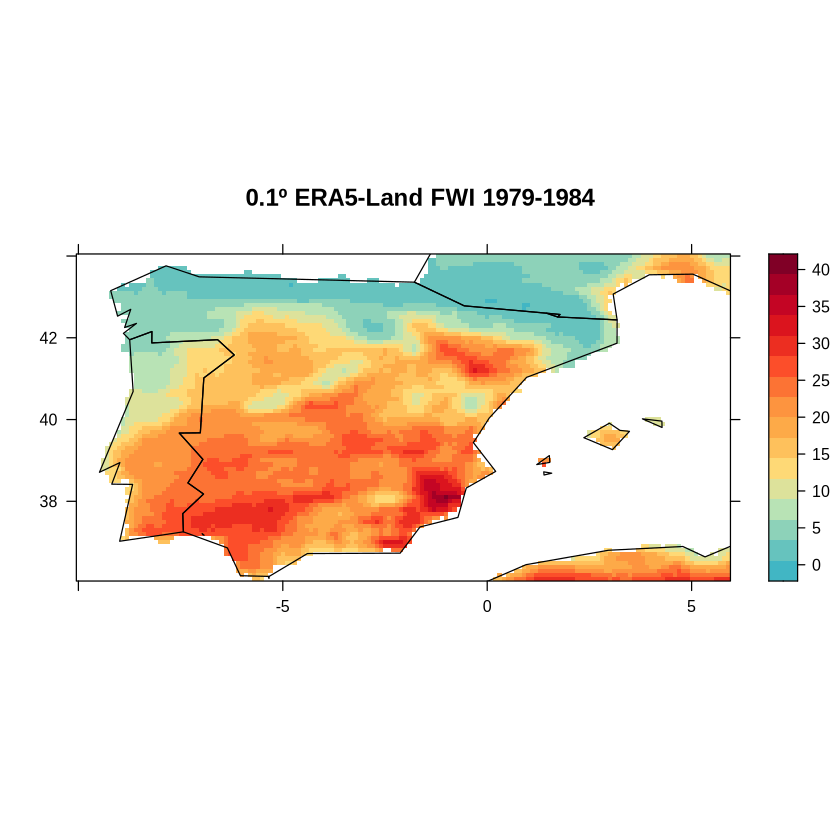

In [12]:
spatialPlot(climatology(yTrain), backdrop.theme = 'countries', col.regions = fwi.colors,
           main = "0.1º ERA5-Land FWI 1979-1984", scales = list(draw = TRUE))

Now, it is time to regrid the data using `interpGrid`:

In [13]:
yTrain <- interpGrid(yTrain,
                     new.coordinates = list(x = seq(-10,5.5,.5),
                                            y = seq(36.5,44,.5)))

[2025-03-21 18:18:56.56132] Calculating nearest neighbors...

[2025-03-21 18:18:56.650846] Performing nearest interpolation... may take a while

[2025-03-21 18:18:56.698941] Done



[2025-03-21 18:18:56.718678] - Computing climatology...

[2025-03-21 18:18:56.73746] - Done.



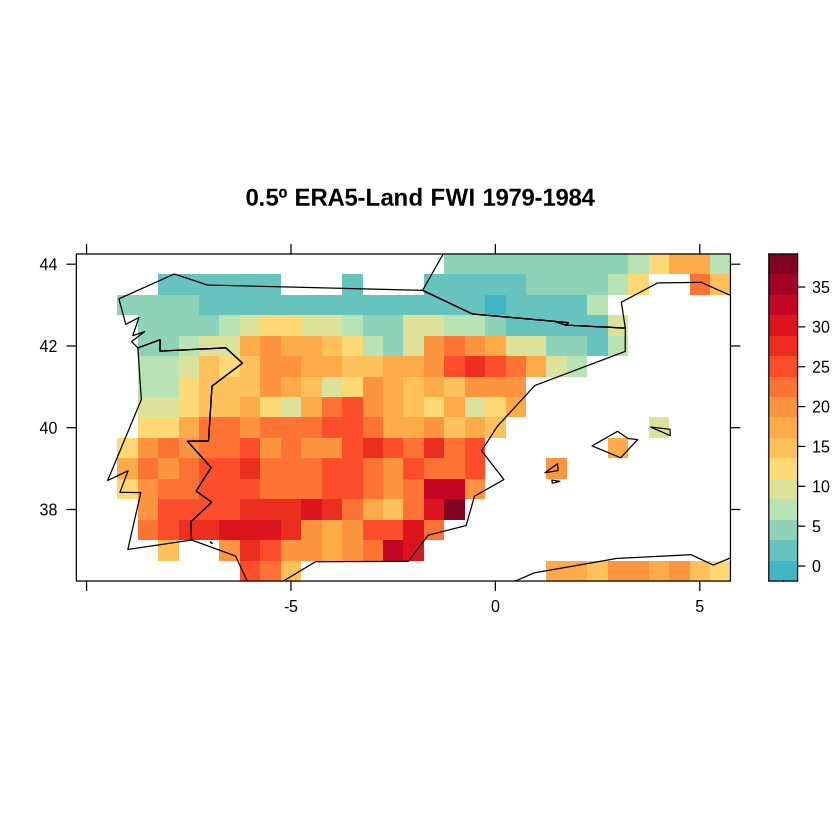

In [14]:
spatialPlot(climatology(yTrain), backdrop.theme = 'countries', col.regions = fwi.colors,
           main = "0.5º ERA5-Land FWI 1979-1984", scales = list(draw = TRUE))

By comparing the spatial plots, the difference in resolution before and after regridding becomes quite evident. The same process is then applied to the predictor variables (i.e., the input data for the deep learning model).

During the data loading process, the variables are directly interpolated before loading by concatenating the `loadGridData` and `interpGrid` functions. The models to be built require that the input and output data share the same spatial structure.

In [15]:
hurs <- loadGridData("data/hurs_Train.nc", var = "hurs", years = 1979:1984) %>% 
  interpGrid(new.coordinates = getCoordinates(yTrain))

t2m <- loadGridData("data/t2m_Train.nc", var = "t2m", years = 1979:1984)  %>% 
  interpGrid(new.coordinates = getCoordinates(yTrain))

sfcwind <- loadGridData("data/sfcwind_Train.nc", var = "sfcwind", years = 1979:1984)  %>% 
  interpGrid(new.coordinates = getCoordinates(yTrain))
  

[2025-03-21 18:18:59.373256] Defining geo-location parameters

[2025-03-21 18:18:59.406919] Defining time selection parameters

[2025-03-21 18:18:59.474283] Retrieving data subset ...

[2025-03-21 18:19:23.382777] Done

[2025-03-21 18:19:24.503876] Calculating nearest neighbors...

[2025-03-21 18:19:24.593188] Performing nearest interpolation... may take a while

[2025-03-21 18:19:24.626036] Done

[2025-03-21 18:19:25.22841] Defining geo-location parameters

[2025-03-21 18:19:25.261137] Defining time selection parameters

[2025-03-21 18:19:25.325693] Retrieving data subset ...

[2025-03-21 18:19:47.484996] Done

[2025-03-21 18:19:48.474966] Calculating nearest neighbors...

[2025-03-21 18:19:48.563301] Performing nearest interpolation... may take a while

[2025-03-21 18:19:48.599154] Done

[2025-03-21 18:19:49.470468] Defining geo-location parameters

[2025-03-21 18:19:49.495883] Defining time selection parameters

[2025-03-21 18:19:49.561516] Retrieving data subset ...

[2025-03-21 18

[2025-03-21 18:20:15.230892] - Computing climatology...

[2025-03-21 18:20:15.242019] - Done.

[2025-03-21 18:20:16.55704] - Computing climatology...

[2025-03-21 18:20:16.568102] - Done.



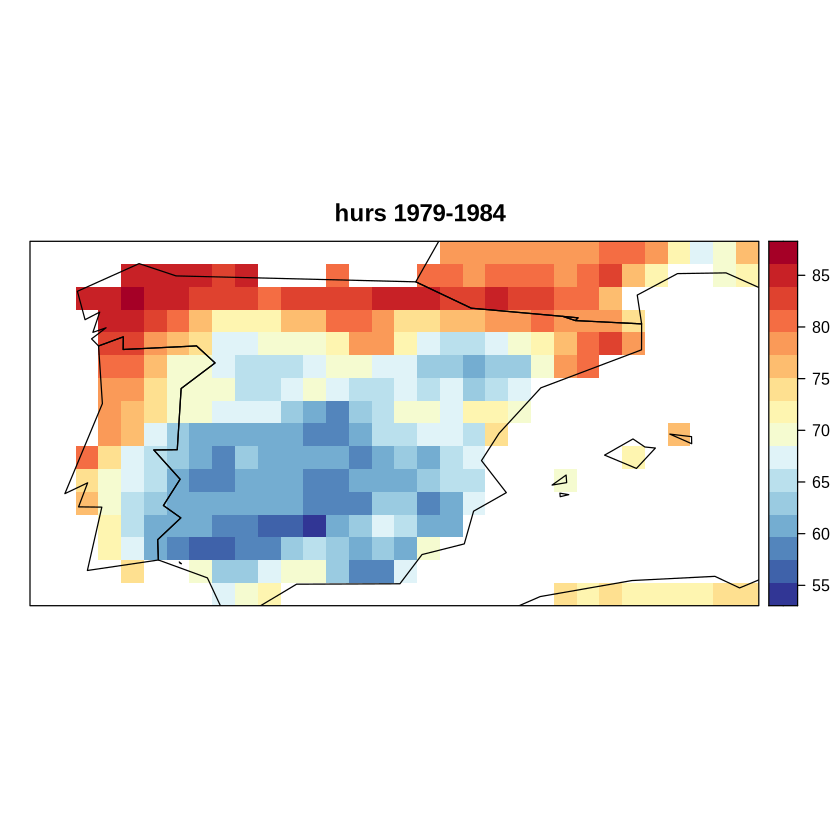

[2025-03-21 18:20:18.684523] - Computing climatology...

[2025-03-21 18:20:18.695745] - Done.



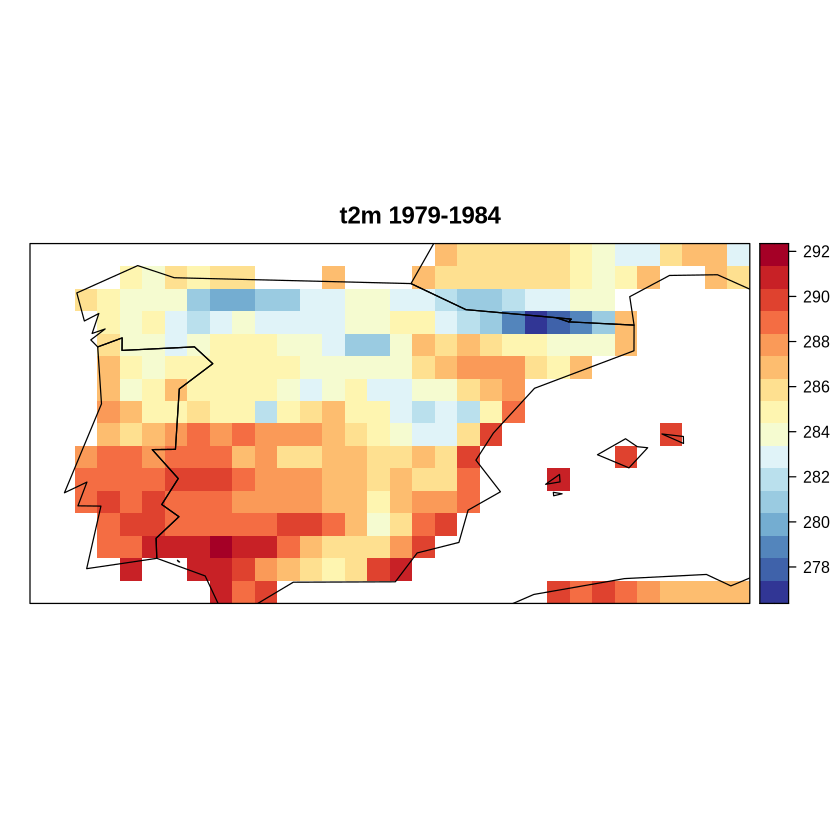

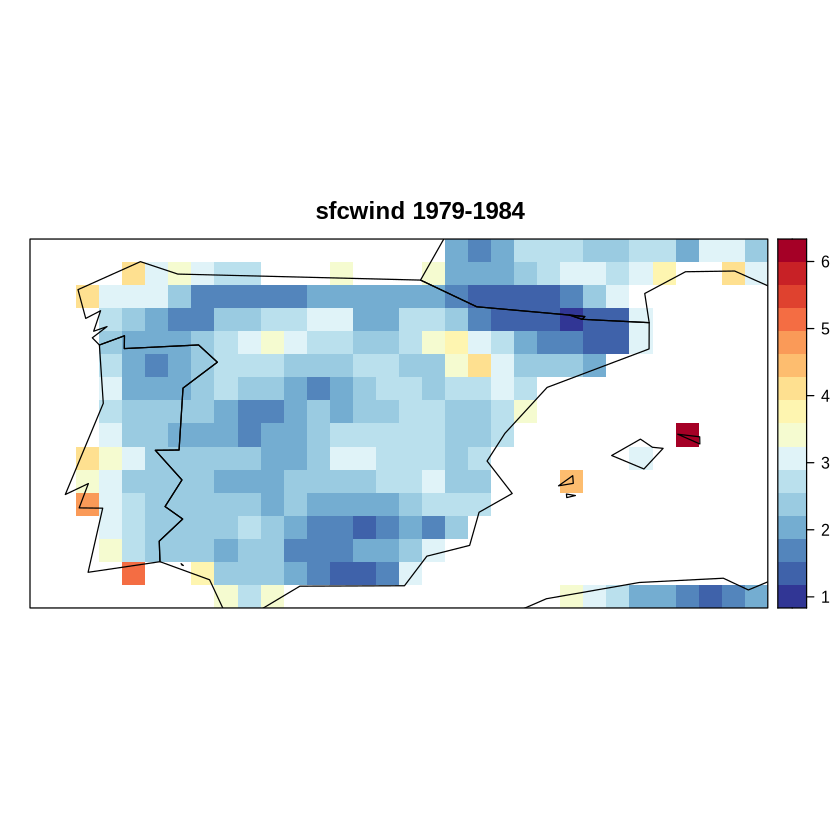

In [16]:
spatialPlot(climatology(hurs), backdrop.theme = 'countries', 
            rev.colors = T, main = "hurs 1979-1984")
spatialPlot(climatology(t2m), backdrop.theme = 'countries', 
            rev.colors = T, main = "t2m 1979-1984")
spatialPlot(climatology(sfcwind), backdrop.theme = 'countries', 
            rev.colors = T, main = "sfcwind 1979-1984")

The predictor variables are combined into a single object, *xTrain*, using the `makeMultiGrid` function. Additionally, it is recommended to remove the *hurs*, *t2m*, and *sfcwind* variables to free up space.

In [17]:
# Combinar los datos cargados en un único objeto xTrain
xTrain <- makeMultiGrid(hurs,t2m,sfcwind)

rm(hurs,t2m,sfcwind)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,2883176,154.0,6573401,351.1,6573401,351.1
Vcells,9527615,72.7,129632410,989.1,202550639,1545.4


Convolutional layers in the U-Net model cannot function correctly if there are **NaN** values in the input data. Therefore, additional preprocessing steps are required. First, we filter out **NaNs** in the predictand by intersecting the temporal dimensions of *xTrain* and *yTrain*, then replacing the **NaNs** with zeros. Finally, the predictors are standardized.

Standardizing predictors is crucial for efficient training and better model performance in deep learning. When features have different scales, gradient descent (commonly used to optimize models) may struggle with convergence. Features with larger values can dominate the learning process, leading to slow or unstable training.

Standardization ensures that all features contribute equally by adjusting them to have a mean of 0 and a standard deviation of 1. This promotes faster convergence, prevents numerical instability, and ensures that weight updates are balanced across all features. Additionally, many weight initialization methods assume standardized data, and standardization helps regularization techniques apply uniformly to all features.

Overall, standardizing predictors improves the training process, ensures balanced feature importance, and leads to better model performance.

In [18]:
# Filter days with NaNs or NA
yTrain <- filterNA(yTrain)

xTrain <- intersectGrid(xTrain, yTrain, which.return = 1)


# Substitute NANs by zero if training CNN_UNET
yTrain$Data[is.na(yTrain$Data)] <- 0

# Standardize predictors
xTrain_stand <- scaleGrid(xTrain, type = 'standardize')

xTrain_stand$Data[is.na(xTrain_stand$Data)] <- 0

NOTE: Some of the specified dimensions do not exist in the grid

NOTE: Some of the specified dimensions do not exist in the grid

[2025-03-21 18:20:21.804851] - Scaling ...

[2025-03-21 18:20:22.121136] - Done



## Deep learning model design

This Jupyter notebook cell defines a function `denseModel` for training a FCD deep learning model.Therefore, the function constructs a corresponding neural network architecture using `Keras`. The image below showcases several deep learning architectures commonly used for FWI emulation. In this notebook, the FCD and U-Net models are designed for a simplified toy example. The DeepESD model is not included due to its high computational cost, which remains prohibitive even for toy datasets.

![Imagen de ejemplo](figs/estructuras.png)


**For the FCD model**, this simpler model consists only of dense (fully connected) layers. It starts with an input layer, followed by two hidden layers with ReLU activation, and ends with a dense output layer with a linear activation function.

The function `prepareData.keras` is used to preprocess the training data (`xTrain_stand` and `yTrain`), adjusting the shape and connection type based on the model's needs. The function is defined to return the compiled model for training.

In [19]:
denseModel <- function(inp){
    inputs <- layer_input(shape = dim(inp$x.global)[2])
    l1 <- layer_dense(inputs, units = 50, activation = 'relu')
    l2 <- layer_dense(l1, units = 50, activation = 'relu')
    outputs <- layer_dense(l2, units = dim(inp$y$Data)[2], activation = 'linear')
    model <- keras_model(inputs = inputs, outputs = outputs)
    
    return(model)
}


In [20]:
xyT <- prepareData.keras(x = xTrain_stand, y = yTrain, 
                         first.connection = 'dense', last.connection = 'dense', 
                         channels = 'last')

This code defines a custom loss function called `loss`, which calculates the **Mean Squared Error (MSE)**, but only for the land areas in a dataset, effectively ignoring the ocean areas during the loss computation.

The function starts by creating a **mask** that identifies which values of `y_true` correspond to land (i.e., values greater than zero). This mask is used to isolate the land regions from the ocean regions, ensuring that the loss is only computed where the data represents land. The mask is applied to both the true labels (`y_true`) and the predicted values (`y_pred`), so that the MSE is calculated only for the land areas, excluding the ocean (where `y_true` is zero).

This approach ensures that the model is trained on land data exclusively, and that any predictions or errors related to the ocean are ignored. The final MSE is computed on the land regions, providing a more focused and accurate measure of model performance over land areas.

In summary, the mask is used to **isolate the land from the sea**, and the loss function is only computed in the land areas, making it ideal for scenarios where predictions over ocean regions are irrelevant.

In [21]:
loss <- function(y_true, y_pred) {
  # Create the mask for the values where y_true > 0
  mask <- k_cast(y_true > 0, dtype = k_floatx())
  
  #Apply the mask
  masked_y_true <- y_true * mask
  masked_y_pred <- y_pred * mask
  
  # Compute MSE for the masked values
  mse <- k_mean(k_square(masked_y_true - masked_y_pred), axis = c(1, 2))
  
  return(mse)
}


## Training phase

Now that the architecture is defined, users must specify the output.file where the trained model will be saved. Then, they should set the compile and fit arguments for the deep learning model, as defined earlier in the notebook or in the .yaml file.

The following code code sets up the configuration and training process for a deep learning model. Below is an explanation of the key steps:

1. **Compilation Arguments (`compile.args`)**:
   - The `loss` function is defined by the `loss` function from earlier in the code (likely a custom loss function).
   - The optimizer used is **Adam**, which is a popular optimization algorithm, with its learning rate set to a value retrieved from `config$params$learning_rate`.

2. **Fitting Arguments (`fit.args`)**:
   - `batch_size` is set to the value defined in `config$params$batch`, which determines how many samples are processed before the model's internal parameters are updated.
   - `epochs` is set to `config$params$epochs`, indicating how many times the model will iterate over the entire training dataset.
   - `validation_split` is set to 0.2, meaning that 20% of the training data will be used for validation.
   - `verbose` is set to `2`, which means progress logs will be displayed in a detailed manner during training.
   - `callbacks` are defined as a list containing two key components:
     - **Early Stopping**: The training process will stop early if there is no improvement in the validation loss after a certain number of epochs (determined by `config$params$patience`).
     - **Model Checkpoint**: The best model (based on validation loss) will be saved to the specified `output.file`, ensuring that only the best model is stored, without saving weights separately.

3. **Model Training**:
   - `input <- xyT$x.global` sets the training input data to `x.global` from the `xyT` object.
   - `dense <- denseModel(xyT)` calls the `denseModel` function to generate the model based on the provided input data (`xyT`).
   - The model is then compiled using the loss function and optimizer defined earlier with `dense$compile()`.

This setup prepares the model for training by specifying how the model should be compiled and how the training process will proceed with configurations for the loss function, optimizer, batch size, epochs, and callbacks like early stopping and model checkpoints.


In [22]:
output.file <- paste0("outputs/dense.h5")

In [23]:
compile.args <- list("loss" = loss,
                     "optimizer" = optimizer_adam(learning_rate = config$params$learning_rate))

In [24]:
fit.args <- list("batch_size" = config$params$batch, 
                 "epochs" = config$params$epochs, 
                 "validation_split" = 0.2, 
                 "verbose" = 2L,
                 "callbacks" = list(callback_early_stopping(patience = config$params$patience), 
                                    callback_model_checkpoint(
                                      filepath = output.file,
                                      monitor = 'val_loss',
                                      save_best_only = TRUE,
                                      save_weights_only = FALSE)))

In [25]:
input <- xyT$x.global

dense <- denseModel(xyT)

In [26]:
dense$compile(loss = compile.args[["loss"]], 
              optimizer = compile.args[["optimizer"]])

In [27]:
start_time <- Sys.time()

In [28]:
dense$fit(input, 
            xyT$y$Data, 
            "batch_size" = fit.args[["batch_size"]], 
            "epochs" = fit.args[["epochs"]], 
            "validation_split" = fit.args[["validation_split"]],
            "verbose" = fit.args[["verbose"]], 
            "callbacks" = fit.args[["callbacks"]])

In [29]:
end_time <- Sys.time()

In [30]:
execution_time <- end_time - start_time
print(paste0("model computing training time: ", execution_time))

[1] "model computing training time: 37.4472985267639"


The following code extracts and visualizes the training and validation loss over the course of the training process.

1. **Extract Loss Values**:
   - `train_loss <- dense$history$history$loss`: Extracts the training loss for each epoch from the model's training history.
   - `val_loss <- dense$history$history$val_loss`: Extracts the validation loss for each epoch from the model's training history.
   - `epochs <- dense$history$epoch`: Retrieves the epoch numbers from the model's training history.

2. **Create DataFrame**:
   - `df <- data.frame(Epoch = epochs, Train_Loss = train_loss, Val_Loss = val_loss)`: A data frame is created with three columns: `Epoch`, `Train_Loss`, and `Val_Loss`, which store the respective values for plotting.

3. **Plotting the Loss Curves**:
   - `ggplot(df, aes(x = Epoch))`: Initializes a `ggplot` object with the data frame `df` and sets the x-axis to represent the epochs.
   - `geom_line(aes(y = Train_Loss, color = "Train Loss"))`: Plots the training loss curve with a blue line.
   - `geom_line(aes(y = Val_Loss, color = "Validation Loss"))`: Plots the validation loss curve with a red line.
   - `labs(title = "Training and Validation Loss", x = "Epoch", y = "Loss")`: Adds a title and labels for the x and y axes.
   - `scale_color_manual(values = c("Train Loss" = "blue", "Validation Loss" = "red"))`: Customizes the colors of the training and validation loss curves.
   - `theme_minimal()`: Applies a minimal theme to the plot for cleaner visualization.

This code generates a line plot that displays how the training and validation loss evolve over epochs, helping to visualize the model's performance during training.

In [31]:
train_loss <- dense$history$history$loss
val_loss <- dense$history$history$val_loss
epochs <- dense$history$epoch

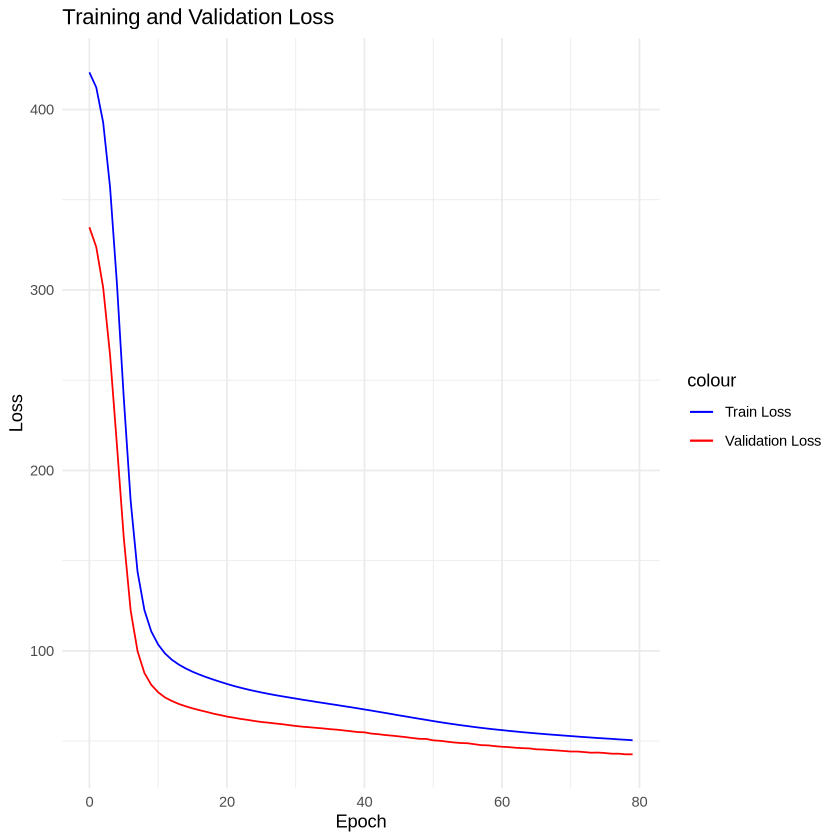

In [32]:
df <- data.frame(Epoch = epochs, Train_Loss = train_loss, Val_Loss = val_loss)

ggplot(df, aes(x = Epoch)) +
  geom_line(aes(y = Train_Loss, color = "Train Loss")) +
  geom_line(aes(y = Val_Loss, color = "Validation Loss")) +
  labs(title = "Training and Validation Loss",
       x = "Epoch",
       y = "Loss") +
  scale_color_manual(values = c("Train Loss" = "blue", "Validation Loss" = "red")) +
  theme_minimal()

This workflow can be repeated with different architecture. Try now with the U-Net architecture following the same steps.

**For the U-Net model**, the function builds a U-Net architecture, which consists of an encoder-decoder structure often used in tasks like image segmentation. The encoder consists of several convolutional layers with batch normalization and ReLU activation, followed by max-pooling layers. The decoder uses transposed convolutions and concatenation with corresponding encoder layers to refine the feature maps. The final layer produces a single-channel output with a linear activation function.

In [33]:
# clear memory and session
rm(dense, input, xyT)
gc()
k_clear_session()


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3055647,163.2,6573401,351.1,6573401,351.1
Vcells,13240080,101.1,103705928,791.3,202550639,1545.4


In [34]:
unetModel <- function(inp){
  inputs <- layer_input(shape = dim(inp$x.global)[2:4]) # TensorShape([None, 80, 160, 3])
  
  # Encoder
  l1_conv1 <- layer_conv_2d(inputs, filters = 64, kernel_size = c(2, 2), activation = 'linear', padding = 'same')
  l1_bn <- layer_batch_normalization(l1_conv1)
  l1 <- layer_activation(l1_bn, activation = 'relu')  # Use layer_activation for ReLU
  l1_mp <- layer_max_pooling_2d(l1, pool_size = c(2, 2))
  
  l2_conv1 <- layer_conv_2d(l1_mp, filters = 128, kernel_size = c(2, 2), activation = 'linear', padding = 'same')
  l2_bn <- layer_batch_normalization(l2_conv1)
  l2 <- layer_activation(l2_bn, activation = 'relu')  # Use layer_activation for ReLU
  l2_mp <- layer_max_pooling_2d(l2, pool_size = c(2, 2))
  
  l3_conv1 <- layer_conv_2d(l2_mp, filters = 256, kernel_size = c(2, 2), activation = 'linear', padding = 'same')
  l3_bn <- layer_batch_normalization(l3_conv1)
  l3 <- layer_activation(l3_bn, activation = 'relu')  # Use layer_activation for ReLU
  l3_mp <- layer_max_pooling_2d(l3, pool_size = c(2, 2))
  
  l4_conv1 <- layer_conv_2d(l3_mp, filters = 512, kernel_size = c(2, 2), activation = 'linear', padding = 'same')
  l4_bn <- layer_batch_normalization(l4_conv1)
  l4 <- layer_activation(l4_bn, activation = 'relu')  # Use layer_activation for ReLU
  l4_mp <- layer_max_pooling_2d(l4, pool_size = c(2, 2))
  
  l5_conv1 <- layer_conv_2d(l4_mp, filters = 1024, kernel_size = c(2, 2), activation = 'linear', padding = 'same')
  l5_bn <- layer_batch_normalization(l5_conv1)
  l5 <- layer_activation(l5_bn, activation = 'relu')  # Use layer_activation for ReLU
  
  # Decoder
  d1 <- layer_conv_2d_transpose(l5, filters = 512, strides = c(2, 2), kernel_size = c(2, 2), activation = 'relu', padding = 'same')
  d1_concat <- layer_concatenate(list(d1, l4), axis = 3)
  d1_conv <- layer_conv_2d(d1_concat, filters = 512, kernel_size = c(2, 2), activation = 'relu', padding = 'same')
  
  d2 <- layer_conv_2d_transpose(d1_conv, filters = 256, strides = c(2, 2), kernel_size = c(2, 2), activation = 'relu', padding = 'same')
  d2_concat <- layer_concatenate(list(d2, l3), axis = 3)
  d2_conv <- layer_conv_2d(d2_concat, filters = 256, kernel_size = c(2, 2), activation = 'relu', padding = 'same')
  
  d3 <- layer_conv_2d_transpose(d2_conv, filters = 128, strides = c(2, 2), kernel_size = c(2, 2), activation = 'relu', padding = 'same')
  d3_concat <- layer_concatenate(list(d3, l2), axis = 3)
  d3_conv <- layer_conv_2d(d3_concat, filters = 128, kernel_size = c(2, 2), activation = 'relu', padding = 'same')
  
  d4 <- layer_conv_2d_transpose(d3_conv, filters = 64, strides = c(2, 2), kernel_size = c(2, 2), activation = 'relu', padding = 'same')
  d4_concat <- layer_concatenate(list(d4, l1), axis = 3)
  d4_conv <- layer_conv_2d(d4_concat, filters = 64, kernel_size = c(2, 2), activation = 'relu', padding = 'same')
  
  # Final decoding (ajuste realizado aquí)
  final_conv <- layer_conv_2d(d4_conv, filters = 1, kernel_size = c(1, 1), activation = 'linear', padding = 'same')
  
  model <- keras_model(inputs = inputs, outputs = final_conv)

  return(model)
}


In [35]:
xyT <- prepareData.keras(x = xTrain_stand, y = yTrain, 
                         first.connection = 'conv', last.connection = 'conv', 
                         channels = 'last')

In [36]:
input <- xyT$x.global

unet <- unetModel(xyT)

<div style="background-color: #fff3cd; border-left: 5px solid #ffeeba; padding: 10px;">
  <strong>Warning:</strong> Running the next cell could take more than 10 minutes.
</div>

In [37]:
compile.args <- list("loss" = loss,
                     "optimizer" = optimizer_adam(learning_rate = config$params$learning_rate))

fit.args <- list("batch_size" = config$params$batch, 
                 "epochs" = config$params$epochs, 
                 "validation_split" = 0.2, 
                 "verbose" = 2L,
                 "callbacks" = list(callback_early_stopping(patience = config$params$patience), 
                                    callback_model_checkpoint(
                                      filepath = output.file,
                                      monitor = 'val_loss',
                                      save_best_only = TRUE,
                                      save_weights_only = FALSE)))

In [38]:
output.file <- paste0("outputs/unet.h5")

In [39]:
unet$compile(loss = compile.args[["loss"]], 
              optimizer = compile.args[["optimizer"]])

In [40]:
start_time <- Sys.time()

In [41]:
unet$fit(input, 
            xyT$y$Data, 
            "batch_size" = fit.args[["batch_size"]], 
            "epochs" = fit.args[["epochs"]], 
            "validation_split" = fit.args[["validation_split"]],
            "verbose" = fit.args[["verbose"]], 
            "callbacks" = fit.args[["callbacks"]])

In [43]:
end_time <- Sys.time()
execution_time <- end_time - start_time
print(paste0("model computing training time: ", execution_time))

[1] "model computing training time: 8.76835868358612"


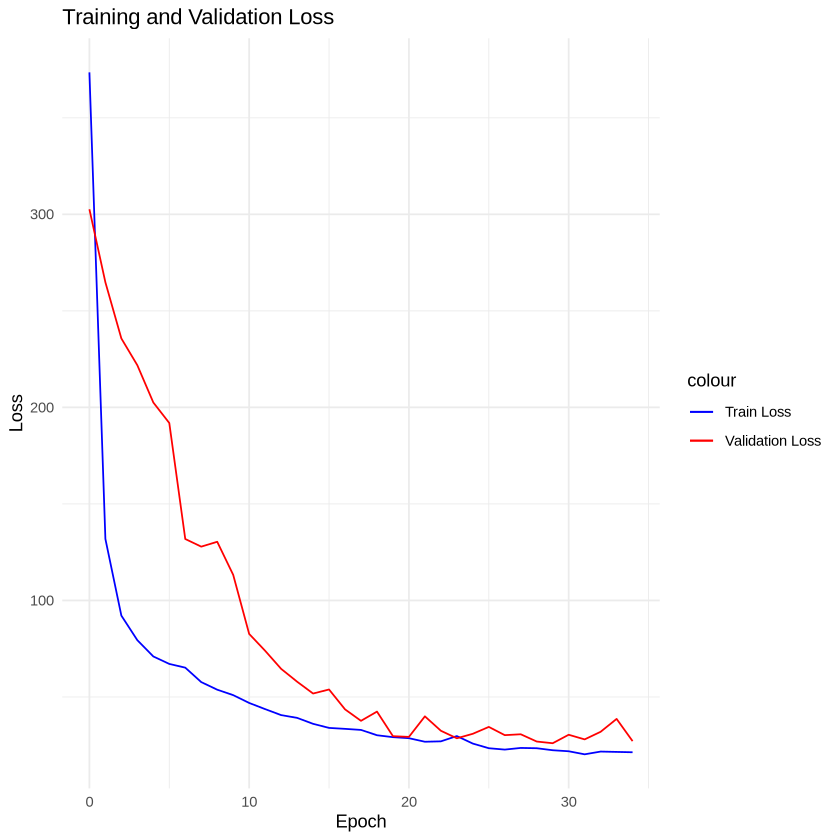

In [45]:
train_loss <- unet$history$history$loss
val_loss <- unet$history$history$val_loss
epochs <- unet$history$epoch

df <- data.frame(Epoch = epochs, Train_Loss = train_loss, Val_Loss = val_loss)

ggplot(df, aes(x = Epoch)) +
  geom_line(aes(y = Train_Loss, color = "Train Loss")) +
  geom_line(aes(y = Val_Loss, color = "Validation Loss")) +
  labs(title = "Training and Validation Loss",
       x = "Epoch",
       y = "Loss") +
  scale_color_manual(values = c("Train Loss" = "blue", "Validation Loss" = "red")) +
  theme_minimal()

In [46]:
rm(yTrain, xTrain_stand, input)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3059366,163.4,6573401,351.1,6573401,351.1
Vcells,13255680,101.2,82964743,633.0,202550639,1545.4


## Prediction phase

This final section begins by loading the test data for the FWI from a NetCDF file, covering the years 2018 to 2021. In this section, a pre-trained U-Net model, trained over nearly 40 years (1979-2017), is provided to users. The standardized inputs and deep learning model are made available here, as preprocessing—especially considering computing time and memory requirements—can be quite expensive. The standardized test predictors are loaded from a previously saved `.Rdata` file (with preprocessing analogous to the xTrain data shown in the Training Phase section). The data is then prepared for prediction using the `prepareNewData`. `Keras` function, which processes both the standardized test predictors and the predefined `xyT` object.

Next, unnecessary objects are removed from memory using `rm()` to free up space, and `gc()` is run to perform garbage collection. The pre-trained model is loaded from an `HDF5` file, and it is compiled using the `Adam` optimizer with a specified learning rate, along with the defined loss function.

Once the model is compiled, predictions are made using the `downscalePredict.keras` function, passing in the prepared test data, model, and loss function. The session is cleared once the predictions are generated.

A mask is created based on the `yTest` data, where missing values (**NA**) are set to zero, values greater than zero are set to one, and zero values are converted to **NA**. This mask is then applied to the predictions by multiplying the predicted values with the mask, ensuring that ocean areas (represented as **NA**) are excluded from the final predictions.

Finally, the climatology of the predictions is visualized using a spatial plot. The plot includes a backdrop of country borders, color regions for FWI values, and labeled axes to help visualize the model's performance on the test data.


In [47]:
yTest <- loadGridData("data/yTest.nc", var = "FWI", years = 2018:2021)

[2025-03-21 18:32:09.780809] Defining geo-location parameters

[2025-03-21 18:32:09.812038] Defining time selection parameters

[2025-03-21 18:32:09.827631] Retrieving data subset ...

[2025-03-21 18:32:21.539031] Done



In [48]:
# Standardize predictors
load("data/xTest_stand.Rdata")

xyT_test <- prepareNewData.keras(xTest_stand, xyT)

rm(xTrain, xTest_stand)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3062168,163.6,6573401,351.1,6573401,351.1
Vcells,84691245,646.2,300060141,2289.3,331218951,2527.1


In [49]:
model <- load_model_hdf5("data/unet_P1.h5", compile = F)

In [50]:
model$compile(
  optimizer = optimizer_adam(learning_rate = config$params$learning_rate),
  loss = loss)

In [51]:
pred <- downscalePredict.keras(xyT_test,
                               model = model,
                               loss = 'mse',
                               C4R.template = yTest,
                               clear.session = TRUE)

Warning message in makeMultiGrid(.):
“One single grid was provided as input”
NOTE: One single grid passed to the function: nothing to bind, so the original grid was returned



In [52]:
mask <- yTest
mask$Data[is.na(mask$Data)] <- 0
mask$Data[mask$Data > 0] <- 1
mask$Data[mask$Data == 0] <- NA

In [53]:
pred <- gridArithmetics(pred, mask, operator = '*')

[2025-03-21 18:34:12.720485] - Computing climatology...

[2025-03-21 18:34:13.088991] - Done.



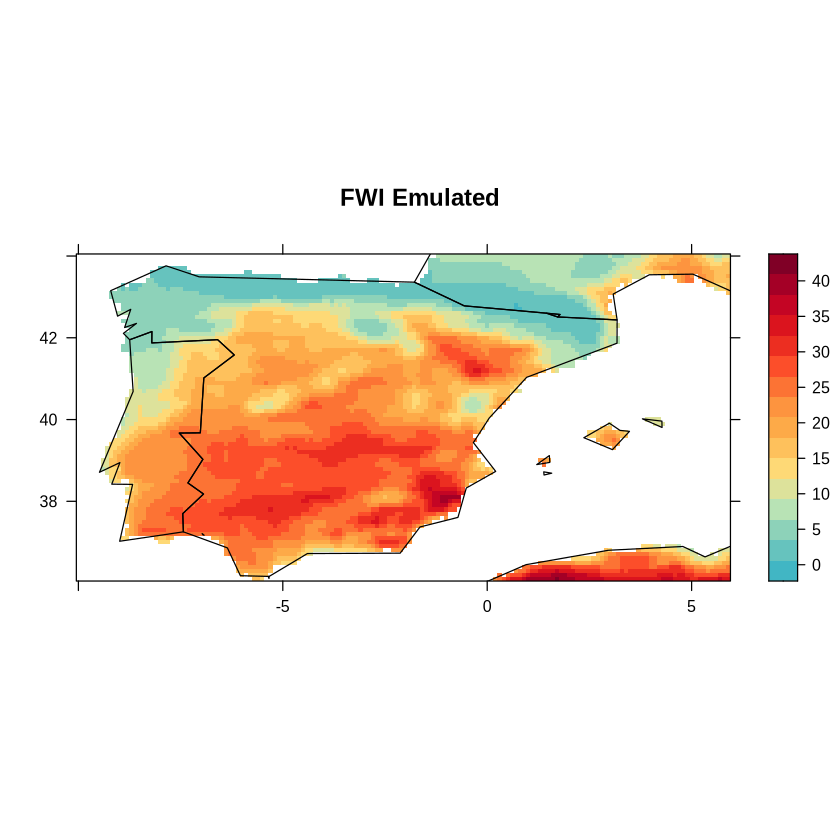

In [54]:
spatialPlot(climatology(pred), backdrop.theme = "countries", 
            col.regions = fwi.colors, main = "FWI Emulated",
           scales = list(draw = TRUE))

## Session info

In [55]:
print(sessionInfo())

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.4 LTS

Matrix products: default
BLAS/LAPACK: /home/oscar/miniconda3/envs/jupyter-env/lib/libopenblasp-r0.3.21.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=es_ES.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=es_ES.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=es_ES.UTF-8          LC_NAME=es_ES.UTF-8          
 [9] LC_ADDRESS=es_ES.UTF-8        LC_TELEPHONE=es_ES.UTF-8     
[11] LC_MEASUREMENT=es_ES.UTF-8    LC_IDENTIFICATION=es_ES.UTF-8

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggplot2_3.4.4          RColorBrewer_1.1-3     yaml_2.3.7            
 [4] magrittr_2.0.3         downscaleR.keras_1.1.1 tensorflow_2.16.0     
 [7] keras_2.15.0           downscale